# Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize, BoundaryNorm
from matplotlib.cm import ScalarMappable
import re

# Load the results

In [16]:

# Choose a planet, greenhouse gas and scenario
pl_name = 'TRAPPIST-1 b'
gg = 'CH4'
scenario = 'H2rich'

# Choose one or multiple nights
nightlist = [
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            # '2023-11-11',
            # '2025-07-08',
               ]

# #---------------------------------------------------#

models_shortname = f'{pl_name[-1]}_{scenario}_{gg}'

if len(nightlist) == 1:
    results_file = f'/home/mathisb/Github/HRS_models/{models_shortname}/{models_shortname}_results_{nightlist[0]}.npy'
else:
    nb_end = "-".join(str(i) for i in range(1, len(nightlist) + 1))
    results_file = f'/home/mathisb/Github/HRS_models/{models_shortname}/{models_shortname}_results_{nb_end}.npy'

results = np.load(results_file, allow_pickle=True)

# Plot one Kp/Vrad map

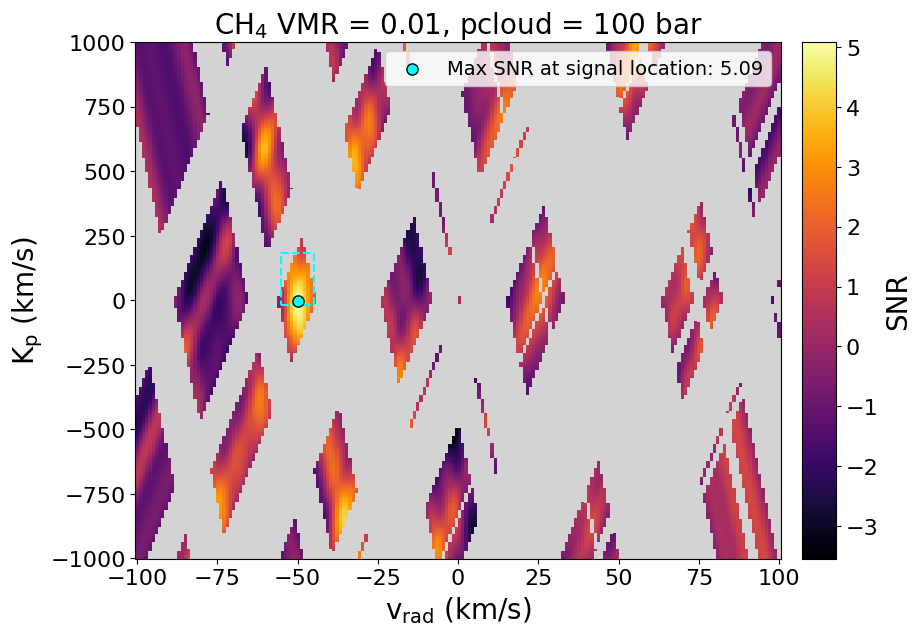

In [17]:

# Choose which map to plot
gg_ab = 0.01     # greenhouse gas abundance
cloud = 100   # cloud deck pressure

#----------------------------------#

# Get values from the model results
selected_model = next(d for d in results if d[gg] == gg_ab and d["Cloud"] == cloud)
RVinj = selected_model['RV_injection']      # RV at which the signal was injected
pl_Kp = selected_model['Planet_Kp']         # Kp of the planet
KpVsys_plot = selected_model['KpVrad_map']  # KpVrad map of the cross-correlation

# Rectangle where to look for signal
box_Vrad = (RVinj - 5, RVinj + 5)
box_Kp = (pl_Kp - 100, pl_Kp + 100)

# Plot one map
fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(100, 42)

ax1 = fig.add_subplot(gs[:96, 2:37])  # Main map
axc = fig.add_subplot(gs[:96, 38:40]) # Colorbar

# Coordinate axes
x = np.linspace(-100, 100, 200)
y = np.linspace(-1000, 1000, 400)

def mol_label(name, in_math=False):
    # Convert H2O -> H_2O, CH4 -> CH_4, etc.
    latex = re.sub(r'(\d+)', r'_\1', name)
    if name == 'H2rich': latex = r'H_2' + '-rich'
    return latex if in_math else rf'$\mathrm{{{latex}}}$'

# Color map
cmap = cm.inferno
cmap.set_bad('lightgrey')  # set NaNs to grey

# Main map
ax1.pcolormesh(x, y, KpVsys_plot, cmap=cmap)

plot_title = f"{mol_label(gg)} VMR = {gg_ab}, pcloud = {cloud} bar"

# Colorbar
norm = Normalize(vmin=np.min(KpVsys_plot), vmax=np.max(KpVsys_plot))
cb = ColorbarBase(axc, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label(label='SNR', fontsize=20)
cb.ax.tick_params(labelsize=16)

# Labels and title
ax1.set_title(plot_title, fontsize=20)
ax1.set_xlabel('$\mathrm{v_{rad}}$ (km/s)', fontsize=20)
ax1.set_ylabel('$\mathrm{K_{p}}$ (km/s)', fontsize=20)
ax1.tick_params(labelsize=16)

# Find the indices corresponding to the box
xmask = (x >= box_Vrad[0]) & (x <= box_Vrad[1])
ymask = (y >= box_Kp[0]) & (y <= box_Kp[1])

# Extract the subarray
signal_box = KpVsys_plot[np.ix_(ymask, xmask)]

# Highest value
max_value = np.max(signal_box)

# Find the position of the maximum within the box
iy_box, ix_box = np.unravel_index(np.argmax(signal_box), signal_box.shape)

# Convert to indices in the full map
iy = np.where(ymask)[0][iy_box]
ix = np.where(xmask)[0][ix_box]

# Coordinates of the maximum
x_max = x[ix]
y_max = y[iy]

# Plot the maximum
ax1.scatter(x_max, y_max, color='aqua', edgecolor='black', s=65, marker='o',
            zorder=11, label=f'Max SNR at signal location: {max_value:.2f}')

# Show the legend
ax1.legend(loc='upper right', fontsize=14)

# Draw rectangle outline for the selected box
rect_x = [box_Vrad[0], box_Vrad[1], box_Vrad[1], box_Vrad[0], box_Vrad[0]]
rect_y = [box_Kp[0], box_Kp[0], box_Kp[1], box_Kp[1], box_Kp[0]]
ax1.plot(rect_x, rect_y, color='aqua', linestyle='dashed', linewidth=1.5, zorder=10)

plt.show()

# Plot injection grid

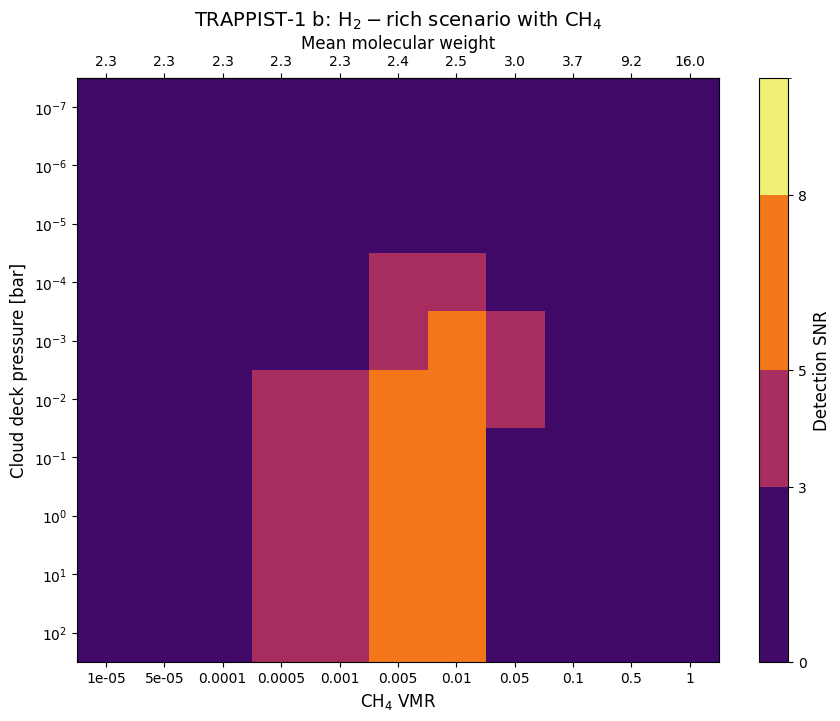

In [4]:
# Coordinate axes of the Kp-Vrad maps
x = np.linspace(-100, 100, 200)
y = np.linspace(-1000, 1000, 400)

# Store the values
ab_values = []
Cloud_values = []
MMW_values = []
SNR_values = []


for model in results:

    ab = model[gg]
    Cloud = model['Cloud']
    RVinj = model['RV_injection']
    pl_Kp = selected_model['Planet_Kp']
    MMW = model['MMW']
    KpVrad_map = model['KpVrad_map']

    # Box around the injected RV and planet Kp
    box_Vrad = (RVinj - 5, RVinj + 5)
    box_Kp = (pl_Kp - 100, pl_Kp + 100)

    xmask = (x >= box_Vrad[0]) & (x <= box_Vrad[1])
    ymask = (y >= box_Kp[0]) & (y <= box_Kp[1])

    signal_box = KpVrad_map[np.ix_(ymask, xmask)]
    max_value = np.max(signal_box)

    ab_values.append(ab)
    Cloud_values.append(Cloud)
    MMW_values.append(MMW)
    SNR_values.append(max_value)


# Unique values (sorted)
pairs = sorted(zip(ab_values, MMW_values), key=lambda x: x[0])

ab_unique = []
MMW_unique = []

seen = set()
for ab, mmw in pairs:
    if ab not in seen:
        seen.add(ab)
        ab_unique.append(ab)
        MMW_unique.append(mmw)

ab_unique = np.array(ab_unique)
MMW_unique = np.array(MMW_unique)
Cloud_unique = np.sort(np.unique(Cloud_values))
log_Cloud_unique = np.log10(Cloud_unique)

# Create 2D SNR grid
snr_grid = np.full((len(Cloud_unique), len(ab_unique)), np.nan)

for abu, Cloud, SNR in zip(ab_values, Cloud_values, SNR_values):

    i = np.where(Cloud_unique == Cloud)[0][0]
    j = np.where(ab_unique == abu)[0][0]

    snr_grid[i, j] = SNR


# ----------------------------------------------------
# Plot
# ----------------------------------------------------

fig, ax = plt.subplots(figsize=(9,7))

# Bounds and colors
bounds = [0, 3, 5, 8, 10]
colors = plt.cm.inferno([0.2, 0.45, 0.7, 0.95])
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(
    snr_grid,
    origin='lower',
    cmap=cmap,
    aspect='equal',
    norm=norm
)

# Tick locations
ax.set_xticks(np.arange(len(ab_unique)))
ax.set_yticks(np.arange(len(Cloud_unique)))

# Tick labels are log10 values
ax.set_xticklabels([f"{v:.3g}" for v in ab_unique])
ax.set_yticklabels([fr"$10^{{{v:.0f}}}$" for v in log_Cloud_unique])

ax.set_xlabel(fr'{mol_label(gg, in_math=False)} VMR', fontsize=12)
ax.set_ylabel(r'Cloud deck pressure [bar]', fontsize=12)
ax.set_title(f"{pl_name}: {mol_label(scenario)} scenario with {mol_label(gg)}", fontsize=14)

ax.invert_yaxis()  # so that low pressures are at the top

# MMW axis
ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks(np.arange(len(MMW_unique)))
ax_top.set_xticklabels([f"{v:.1f}" for v in MMW_unique])
ax_top.set_xlabel("Mean molecular weight", fontsize=12)

# # Write SNR values inside each square
# for i in range(len(Cloud_unique)):
#     for j in range(len(ab_unique)):

#         value = snr_grid[i, j]
#         r, g, b, _ = cmap(norm(value))  # get the brightness of the cell colour
#         brightness = 0.299*r + 0.587*g + 0.114*b  # perceived brightness (standard luminance)

#         text_color = 'slategrey' if brightness > 0.8 else 'white'

#         ax.text(
#             j,
#             i,
#             f'{value:.2f}',
#             ha='center',
#             va='center',
#             color=text_color,
#             fontsize=12,
#             fontweight='bold'
#         )

# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    boundaries=bounds,
    ticks=[0, 3, 5, 8],
    spacing='proportional'
)

cbar.set_ticklabels(['0', '3', '5', '8'])

cbar.set_label('Detection SNR', fontsize=12)

# # Show 3 sig and 5 sig
# contours = ax.contour(
#     snr_grid,
#     levels=[3, 5],
#     colors=['white', 'red'],
#     linewidths=2     )
# ax.clabel(contours, fmt='%dσ', fontsize=10)

plt.tight_layout()
plt.show()

# TEMP PLOT FOR ARTICLE

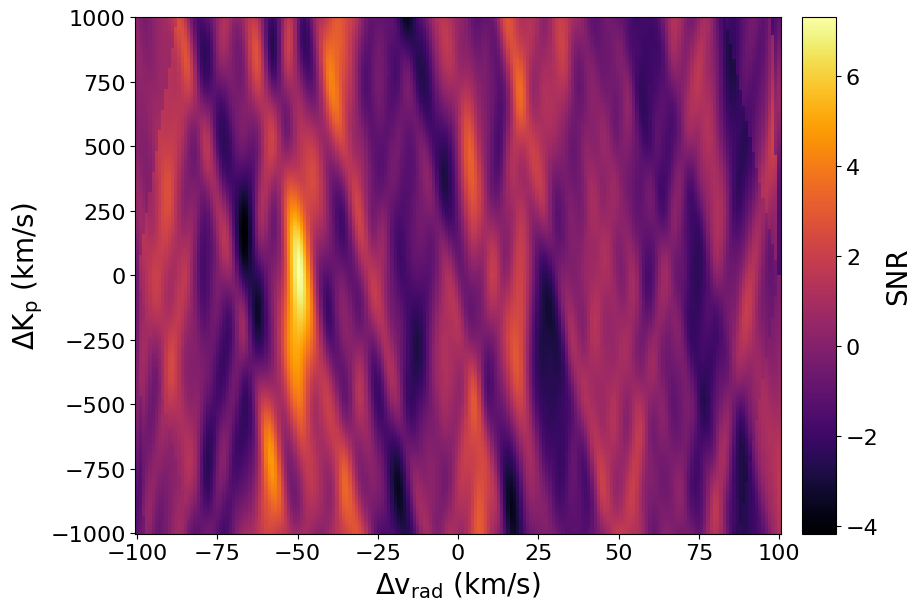

In [20]:

# Choose which map to plot
gg_ab = 0.01     # greenhouse gas abundance
cloud = 100   # cloud deck pressure

#----------------------------------#

# Get values from the model results
selected_model = next(d for d in results if d[gg] == gg_ab and d["Cloud"] == cloud)
RVinj = selected_model['RV_injection']      # RV at which the signal was injected
KpVsys_plot = selected_model['KpVrad_map']  # KpVrad map of the cross-correlation

# Rectangle where to look for signal
box_Vrad = (RVinj - 5, RVinj + 5)
box_Kp = (-100,100)

# Plot one map
fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(100, 42)

ax1 = fig.add_subplot(gs[:96, 2:37])  # Main map
axc = fig.add_subplot(gs[:96, 38:40]) # Colorbar

# Coordinate axes
x = np.linspace(-100, 100, 200)
y = np.linspace(-1000, 1000, 400)

def mol_label(name, in_math=False):
    # Convert H2O -> H_2O, CH4 -> CH_4, etc.
    latex = re.sub(r'(\d+)', r'_\1', name)
    if name == 'H2rich': latex = r'H_2' + '-rich'
    return latex if in_math else rf'$\mathrm{{{latex}}}$'

KpVsys_plot = selected_model['KpVrad_map']
ax1.pcolormesh(x, y, KpVsys_plot, cmap='inferno')

plot_title = f"{mol_label(gg)} VMR = {gg_ab}, pcloud = {cloud} bar"


# Colorbar
cmap = cm.inferno
norm = Normalize(vmin=np.min(KpVsys_plot), vmax=np.max(KpVsys_plot))
cb = ColorbarBase(axc, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label(label='SNR', fontsize=20)
cb.ax.tick_params(labelsize=16)

# Labels and title
# ax1.set_title(plot_title, fontsize=20)
ax1.set_xlabel('$\Delta \mathrm{v_{rad}}$ (km/s)', fontsize=20)
ax1.set_ylabel('$\Delta \mathrm{K_{p}}$ (km/s)', fontsize=20)
ax1.tick_params(labelsize=16)

# # Find the indices corresponding to the box
# xmask = (x >= box_Vrad[0]) & (x <= box_Vrad[1])
# ymask = (y >= box_Kp[0]) & (y <= box_Kp[1])

# # Extract the subarray
# signal_box = KpVsys_plot[np.ix_(ymask, xmask)]

# # Highest value
# max_value = np.max(signal_box)

# # Find the position of the maximum within the box
# iy_box, ix_box = np.unravel_index(np.argmax(signal_box), signal_box.shape)

# # Convert to indices in the full map
# iy = np.where(ymask)[0][iy_box]
# ix = np.where(xmask)[0][ix_box]

# # Coordinates of the maximum
# x_max = x[ix]
# y_max = y[iy]

# Plot the maximum
# ax1.scatter(x_max, y_max, color='aqua', edgecolor='black', s=65, marker='o',
#             zorder=11, label=f'Max SNR at signal location: {max_value:.2f}')

# Show the legend
# ax1.legend(loc='upper right', fontsize=14)

# Draw rectangle outline for the selected box
# rect_x = [box_Vrad[0], box_Vrad[1], box_Vrad[1], box_Vrad[0], box_Vrad[0]]
# rect_y = [box_Kp[0], box_Kp[0], box_Kp[1], box_Kp[1], box_Kp[0]]
# ax1.plot(rect_x, rect_y, color='aqua', linestyle='dashed', linewidth=1.5, zorder=10)

plt.show()

In [18]:
# file1 = '/home/mathisb/Github/HRS_models/b_H2rich_NH3/b_H2rich_NH3_results_2024-07-11b_1111.npy'
# file2 = '/home/mathisb/Github/HRS_models/b_H2rich_NH3/b_H2rich_NH3_results_2024-07-11b_22.npy'
# combined_file = '/home/mathisb/Github/HRS_models/b_H2rich_NH3/b_H2rich_NH3_results_2024-07-11b.npy'

# results1 = np.load(file1, allow_pickle=True)
# results2 = np.load(file2, allow_pickle=True)

# results_combined = list(results1) + list(results2)

# np.save(combined_file, results_combined, allow_pickle=True)

7.318473998734928